In [1]:
import torch
import matplotlib.pyplot as plt

# ----------------------------
# Function Definitions (Torch)
# ----------------------------

def sample_q(n: int,
             mus: torch.Tensor,
             covs: torch.Tensor,
             weights: torch.Tensor) -> torch.Tensor:
    """
    Sample n points from a mixture of d-dimensional Gaussians using PyTorch.
    
    Args:
        n: Number of samples to draw.
        mus: Tensor of shape (K, d) containing the means of each component.
        covs: Tensor of shape (K, d, d) containing the covariance matrices.
        weights: 1D tensor of length K with mixture weights (should sum to 1).
    
    Returns:
        samples: Tensor of shape (n, d) of drawn samples.
    """
    # Draw component indices according to the mixture weights
    comps = torch.multinomial(weights, n, replacement=True)  # (n,)

    # Gather the means and covariances for the chosen components
    chosen_means = mus[comps]       # (n, d)
    chosen_covs = covs[comps]       # (n, d, d)

    # Create a batched multivariate normal distribution
    mvn = torch.distributions.MultivariateNormal(
        loc=chosen_means,
        covariance_matrix=chosen_covs
    )

    # Sample from the batched distribution
    samples = mvn.sample()          # (n, d)
    return samples

def velocity_field(x: torch.Tensor,
                   t: float,
                   X_ref: torch.Tensor,
                   sigma_min: float,
                   method: str = 'mc') -> torch.Tensor:
    """
    Compute the velocity field u_t(x) at time t given reference samples X_ref,
    for d-dimensional data.

    Args:
        x: Tensor of shape (B, d) for current particle positions.
        t: float, current time.
        X_ref: Tensor of shape (N, d) for reference sample points.
        sigma_min: float, minimum noise level.
        method: str, one of 'mc', 'gaussian', 'affine'.

    Returns:
        Tensor of shape (B, d) giving velocities for each of the B particles.
    """
    B, d = x.shape
    device, dtype = x.device, x.dtype

    if method == 'mc':
        # Monte Carlo approximation of u_t(x)
        denom = 1.0 - (1.0 - sigma_min) * t
        diffs = x.unsqueeze(1) - t * X_ref.unsqueeze(0)       # (B, N, d)
        sq = torch.sum(diffs ** 2, dim=2)                     # (B, N)
        alphas = torch.exp(-0.5 * sq / (denom ** 2))          # (B, N)
        w = alphas / (alphas.sum(dim=1, keepdim=True) + 1e-12)
        x_bar = w @ X_ref                                     # (B, d)
        return (x_bar - (1 - sigma_min) * x) / denom          # (B, d)

    # Estimate Gaussian parameters from samples
    m = X_ref.mean(dim=0)                                    # (d,)
    diff = X_ref - m                                         # (N, d)
    C = diff.T @ diff / (X_ref.size(0) - 1)                  # (d, d)

    if method == 'gaussian':
        # Closed‐form Gaussian flow matching (affine form)
        I = torch.eye(d, device=device, dtype=dtype)
        eigvals, eigvecs = torch.linalg.eigh(C)                      # (d,), (d,d)
        A = eigvecs @ torch.diag(torch.sqrt(eigvals)) @ eigvecs.T    # C^{1/2}

        mu_t = t * m                                               # (d,)
        dot_mu = m                                                 # (d,)

        S_t = (1 - t) * I + t * A
        A_mat = (A - I) @ torch.linalg.inv(S_t)                   # (d, d)

        return dot_mu + (x - mu_t) @ A_mat.T                      # (B, d)

    if method == 'affine':
        # Affine MC-CFM velocity: v_t(x) = A_t x + b_t
        I = torch.eye(d, device=device, dtype=dtype)
        sigma_t = 1.0 - (1.0 - sigma_min) * t
        alpha = (1.0 - sigma_min) / sigma_t

        num = t * C - (sigma_t**2) * alpha * I                   # (d, d)
        den = t**2 * C + (sigma_t**2) * I                        # (d, d)
        A_t = num @ torch.linalg.inv(den)                        # (d, d)
        b_t = m - t * (A_t @ m)                                  # (d,)

        return x @ A_t.T + b_t                                   # (B, d)

    raise ValueError(f"Unsupported method: {method}")


def generate_flow_samples(N_gen: int,
                          L_steps: int,
                          dt: float,
                          X_ref: torch.Tensor,
                          sigma_min: float,
                          method: str = 'mc',
                          seed: int = None):
    """
    Generate N_gen samples by pushing standard normal samples through
    flow‐matching dynamics via Euler integration, for d-dimensional data.

    Args:
        N_gen: Number of samples to generate.
        L_steps: Number of time steps.
        dt: Time step size.
        X_ref: Tensor of reference samples, shape (N_ref, d).
        sigma_min: Minimum noise level.
        method: Velocity computation method, e.g. 'mc', 'gaussian', 'affine'.
        seed: Optional random seed for reproducibility.

    Returns:
        Z0: Initial samples from N(0, I), shape (N_gen, d).
        X_gen: Final samples after flow, shape (N_gen, d).
    """
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    N_ref, d = X_ref.shape
    Z0 = torch.randn(N_gen, d, device=X_ref.device, dtype=X_ref.dtype)
    X_gen = Z0.clone()

    for l in range(L_steps):
        t = l * dt
        u = velocity_field(X_gen, t, X_ref, sigma_min, method)  # (N_gen, d)
        X_gen = X_gen + dt * u

    return Z0, X_gen

import torch
import matplotlib.pyplot as plt

def visualize_flow(Z0: torch.Tensor,
                   X_gen: torch.Tensor,
                   X_ref: torch.Tensor,
                   colors):
    """
    Visualize initial and final samples colored by nearest reference sample.
    For d > 2, only the first two dimensions are used for plotting.
    
    Args:
        Z0: Initial samples, tensor of shape (N_gen, d).
        X_gen: Final samples after flow, tensor of shape (N_gen, d).
        X_ref: Reference points, tensor of shape (K, d).
        colors: Array-like of length K with colors for each reference point.
    """
    # If dimensionality > 2, restrict to first two dimensions for visualization
    Z0_plot = Z0[:, :2] if Z0.shape[1] > 2 else Z0
    X_gen_plot = X_gen[:, :2] if X_gen.shape[1] > 2 else X_gen
    X_ref_plot = X_ref[:, :2] if X_ref.shape[1] > 2 else X_ref

    # Compute distances and find nearest reference index for each final point
    dists = torch.norm(X_gen_plot.unsqueeze(1) - X_ref_plot.unsqueeze(0), dim=2)  # (N_gen, K)
    nearest_idx = dists.argmin(dim=1).cpu().numpy()                              # (N_gen,)

    # Convert tensors to NumPy for plotting
    Z0_np = Z0_plot.cpu().numpy()
    X_gen_np = X_gen_plot.cpu().numpy()
    X_ref_np = X_ref_plot.cpu().numpy()

    # Plot
    plt.figure(figsize=(10, 5))

    # Initial samples
    plt.subplot(1, 2, 1)
    plt.scatter(X_ref_np[:, 0], X_ref_np[:, 1], c=colors, s=80, marker='X')
    plt.scatter(Z0_np[:, 0], Z0_np[:, 1], c=[colors[i] for i in nearest_idx],
                s=10, alpha=0.5)
    plt.title("Initial Samples by Nearest Target")
    plt.axis('equal')

    # Final samples
    plt.subplot(1, 2, 2)
    plt.scatter(X_ref_np[:, 0], X_ref_np[:, 1], c=colors, s=80, marker='X')
    plt.scatter(X_gen_np[:, 0], X_gen_np[:, 1], c=[colors[i] for i in nearest_idx],
                s=10, alpha=0.6)
    plt.title("Final Samples by Nearest Target")
    plt.axis('equal')

    plt.tight_layout()
    plt.show()



In [5]:
import torch
import matplotlib.pyplot as plt
import math
from itertools import product


def compute_likelihood(X: torch.Tensor,
                       y: torch.Tensor,
                       H: torch.Tensor,
                       sigma: float) -> torch.Tensor:
    """
    Compute L(x; y) = N(y | Hx, sigma^2 I) at each row of X, for d-dimensional x.
    
    Args:
        X: tensor of shape (M, d) — points at which to evaluate
        y: tensor of shape (k,) — observed vector
        H: tensor of shape (k, d) — linear mapping
        sigma: observation noise std (scalar)
    
    Returns:
        Tensor of shape (M,) giving likelihood at each X[i].
    """
    # Hx: (M, k)
    Hx = X.matmul(H.t())
    diffs = Hx - y.unsqueeze(0)                              # (M, k)
    exponent = -0.5 * torch.sum(diffs**2, dim=1) / (sigma**2)  # (M,)
    k = H.shape[0]
    const = (1.0 / ((2 * math.pi * sigma**2) ** (k / 2)))
    return const * torch.exp(exponent)


def compute_J(X: torch.Tensor,
              y: torch.Tensor,
              H: torch.Tensor,
              sigma: float) -> torch.Tensor:
    """
    Compute the quadratic form 0.5 * ||Hx - y||^2 / sigma^2 for each row of X.
    
    Args:
        X: tensor of shape (M, d)
        y: tensor of shape (k,)
        H: tensor of shape (k, d)
        sigma: observation noise std (scalar)
    
    Returns:
        Tensor of shape (M,) giving 0.5 * ||Hx - y||^2 / sigma^2 for each X[i].
    """
    Hx = X.matmul(H.t())                              # (M, k)
    diffs = Hx - y.unsqueeze(0)                       # (M, k)
    return 0.5 * torch.sum(diffs**2, dim=1) / (sigma**2)


def compute_mixture_density(X: torch.Tensor,
                            mus: torch.Tensor,
                            covs: torch.Tensor,
                            weights: torch.Tensor) -> torch.Tensor:
    """
    Compute the density of a d-dimensional Gaussian mixture at each row of X.
    
    Args:
        X: tensor of shape (M, d)
        mus: tensor of shape (K, d)
        covs: tensor of shape (K, d, d)
        weights: tensor of length K (mixture weights, sum to 1)
    
    Returns:
        Tensor of shape (M,) giving mixture density at each X[i].
    """
    M, d = X.shape
    total = torch.zeros(M, dtype=X.dtype, device=X.device)
    two_pi = 2 * math.pi

    for mu, cov, w in zip(mus, covs, weights):
        inv_cov = torch.inverse(cov)                     # (d, d)
        det_cov = torch.det(cov)                         # scalar
        norm_const = 1.0 / ((two_pi ** (d / 2)) * torch.sqrt(det_cov))
        diff = X - mu.unsqueeze(0)                       # (M, d)
        exp_term = torch.exp(-0.5 * torch.sum(diff @ inv_cov * diff, dim=1))
        total += w * norm_const * exp_term

    return total


def make_density_functions(mus: torch.Tensor,
                           covs: torch.Tensor,
                           weights: torch.Tensor,
                           H: torch.Tensor,
                           y_obs: torch.Tensor,
                           sigma_obs: float):
    """
    Returns two callables:
      prior_density(x: Tensor[N,d]) -> Tensor[N]
      posterior_density(x: Tensor[N,d]) -> Tensor[N]
    where posterior is unnormalized (prior * likelihood).
    
    Relies on your existing:
      - compute_mixture_density(X, mus, covs, weights)
      - compute_likelihood(X, y_obs, H, sigma_obs)
    """

    def prior_density(x: torch.Tensor) -> torch.Tensor:
        """
        x: [N, d]
        returns: [N] p(x) under the Gaussian mixture prior
        """
        return compute_mixture_density(x, mus, covs, weights)

    def posterior_density(x: torch.Tensor) -> torch.Tensor:
        """
        x: [N, d]
        returns: [N] unnormalized posterior p(x)·L(x; y_obs)
        """
        prior_vals = prior_density(x)                                     # [N]
        like_vals  = compute_likelihood(x, y_obs, H, sigma_obs)           # [N]
        return prior_vals * like_vals

    return prior_density, posterior_density



def visualize_marginals(grid_specs: list,
                        prior_fn,
                        posterior_fn):
    """
    Numerically compute and plot exact marginals of a d-dimensional prior
    and unnormalized posterior over the first two dimensions by
    Riemann–summing out dims 3..d.

    Args:
        grid_specs: list of length d, each entry is (x_min, x_max, n_points).
                    e.g. for d=4:
                      [
                        (x1_min, x1_max, n1),
                        (x2_min, x2_max, n2),
                        (x3_min, x3_max, n3),  # “hidden” dims can use small n3
                        (x4_min, x4_max, n4)
                      ]
        prior_fn:       callable x->[N]  (N points in R^d)
        posterior_fn:   callable x->[N]
    """
    d = len(grid_specs)
    # 1) build 1D grids and spacing for each dimension
    axes_1d = []
    deltas = []
    for (lo, hi, n) in grid_specs:
        xs = torch.linspace(lo, hi, n)
        axes_1d.append(xs)
        if n == 1:
            deltas.append(0)
        else:
            deltas.append((hi - lo) / (n - 1))

    # 2) form full mesh; flatten to [M, d] points
    #    careful: torch.meshgrid on variable number of axes
    mesh = torch.meshgrid(*axes_1d, indexing='xy')
    # each mesh[i] has shape [n1, n2, ..., nd]
    # flatten:
    stacked = torch.stack([m.reshape(-1) for m in mesh], dim=1)  # [M, d]

    # 3) evaluate densities
    sizes = [n for (_, _, n) in grid_specs]
    prior_vals = prior_fn(stacked).reshape(*sizes)
    post_vals  = posterior_fn(stacked).reshape(*sizes)

    # 4) marginalize out dims 3..d by averaging (constant scale factor omitted)
    if d > 2:
        sum_axes = tuple(range(2, d))
        # average over hidden dims:
        prior2d = prior_vals.mean(dim=sum_axes)
        post2d  = post_vals.mean(dim=sum_axes)
    else:
        prior2d = prior_vals
        post2d  = post_vals

    # 5) plot heatmaps over dims 1 and 2
    x1_min, x1_max, n1 = grid_specs[0]
    x2_min, x2_max, n2 = grid_specs[1]
    extent = (x1_min, x1_max, x2_min, x2_max)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, data, title in zip(axes,
                               (prior2d.cpu().numpy(), post2d.cpu().numpy()),
                               ("Prior marginal", "Unnormalized posterior")):
        im = ax.imshow(data,
                       extent=extent,
                       origin='lower',
                       aspect='auto')
        ax.set_title(title)
        ax.set_xlabel("x₁")
        ax.set_ylabel("x₂")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()
    
    return prior2d, post2d

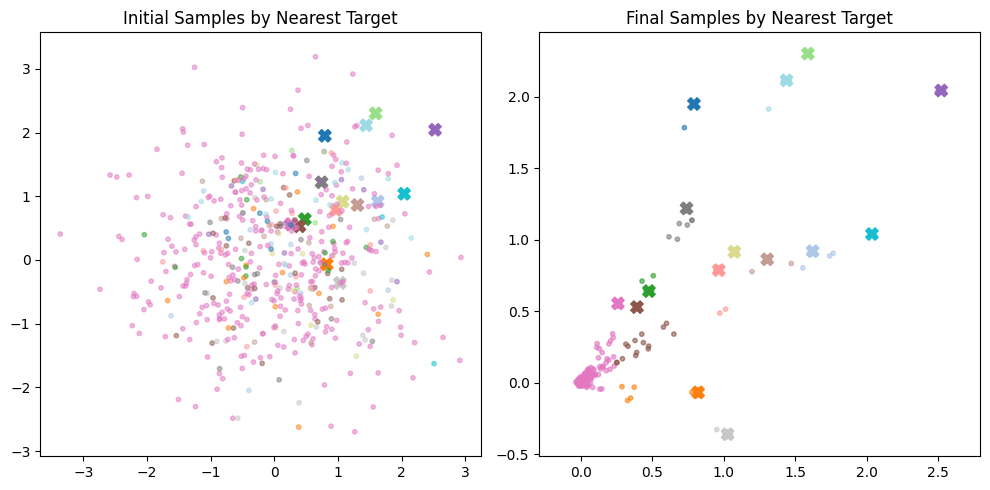

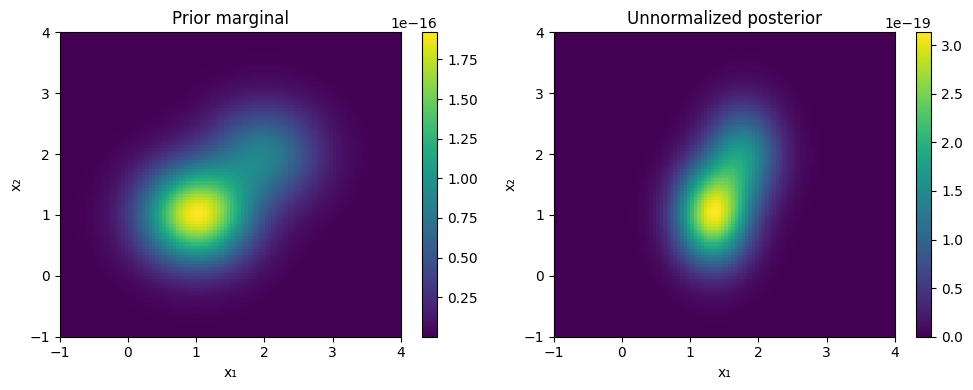

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Main: Parameter Settings and Execution (Torch)
# ----------------------------

# Monte Carlo and generation settings
N_mc      = 15
N_gen     = 500
sigma_min = 1e-2
L_steps   = 100
dt        = 1.0 / L_steps

# dimension
d = 50
# target Gaussian mixture parameters (convert to torch tensors)
mus     = torch.tensor([[1.0] * d,
                        [2.0] * d], dtype=torch.float32)            # (K=2, 2)
covs    = torch.stack([0.3 * torch.eye(d),
                       0.3 * torch.eye(d)], dim=0)                  # (K=2, 2, 2)
weights = torch.tensor([0.7, 0.3], dtype=torch.float32)               # (K,)

# sample reference targets
X_mc = sample_q(N_mc, mus, covs, weights)                              # (N_mc, 2)

# assign colors for each reference sample (for plotting)
colors = plt.cm.tab20(np.linspace(0, 1, N_mc))

# generate flow‐matched samples (Gaussian displacement interpolation)
Z0, X_gen_1 = generate_flow_samples(
    N_gen, L_steps, dt, X_mc, sigma_min,
    method='mc', seed=42
)  # both (N_gen, 2)

# visualize the transformation with torch‐based functions
visualize_flow(Z0, X_gen_1, X_mc, colors)

# # Gaussian flow–matched samples: print mean, then covariance
# print("Gaussian flow–matched samples mean:")
# print(X_gen_1.mean(dim=0))
# print("Gaussian flow–matched samples covariance:")
# print(X_gen_1.T.cov())

# generate flow‐matched samples (optimal‐transport affine)
# Z0, X_gen_2 = generate_flow_samples(
#     N_gen, L_steps, dt, X_mc, sigma_min,
#     method='affine', seed=42
# )  # both (N_gen, 2)

# visualize the transformation with torch‐based functions
# visualize_flow(Z0, X_gen_2, X_mc, colors)

# # Affine flow–matched samples: print mean, then covariance
# print("Affine flow–matched samples mean:")
# print(X_gen_2.mean(dim=0))
# print("Affine flow–matched samples covariance:")
# print(X_gen_2.T.cov())

# compare the two sets
# print("Average L2 distance between Gaussian and affine samples:")
# print(torch.norm(X_gen_1 - X_gen_2, dim=1).mean())
# print(torch.norm(X_gen_1 - X_gen_2, dim=1).shape)


# ----------------------------
# Heatmap Visualization
# ----------------------------
grid_specs = [
    (-1.0, 4.0, 100),   
    (-1.0, 4.0, 100),   
]

# For dims 3…d you can choose coarser or wider ranges, e.g. only 5 points each:
for _ in range(2, d):
    grid_specs.append((1.5, 1.5, 1))

# observation indices: 0, 2, 4, ... up to d-1
obs_idx = torch.arange(0, d, 2)           # (k,)
k = obs_idx.numel()

# build H of shape (k, d), picking out the first of each pair
H = torch.zeros(k, d, dtype=torch.float32)
H[torch.arange(k), obs_idx] = 1.0         # one‐hot rows at positions 0,2,4,...

# y_obs must now be length k, containing the observations at those indices
y_obs = torch.tensor([1.6] * int(d/2), dtype=torch.float32)   # shape (k,)
sigma_obs = 0.5                                                        # scalar

# plot original density, likelihood, and posterior heatmaps
prior_fn, post_fn = make_density_functions(
    mus, covs, weights, H, y_obs, sigma_obs
)

prior2d, post2d = visualize_marginals(grid_specs, prior_fn, post_fn)

In [8]:
import torch
import torch.nn.functional as F
from typing import Tuple

def guidance(
    xt: torch.Tensor,
    x1_samples: torch.Tensor,
    t,
    sigma_min: float,
    J_fn,
    dot_xt_unguided: torch.Tensor = None,
    method: str = "mc",
    M: int = 10,
    v_fn=None,
) -> torch.Tensor:
    """
    Compute the guidance vector field g_t(x) via three methods:
      - "mc"        : Monte Carlo estimator
      - "local"     : local gradient-based
      - "time-affine": fit g(x) = A_t x + b_t by weighted least squares

    Args:
        xt:               [B, D] current states (used for output shape)
        x1_samples:       [N, D] posterior samples from p(x1)
        t:                float or [B] tensor in [0,1]
        sigma_min:        float endpoint variance parameter
        J_fn:             Callable mapping [N, D] → [N], energy J(x1)
        dot_xt_unguided:  [B, D] unguided velocity v_t(x) (local mode)
        method:           "mc", "local", or "time-affine"
        M:                int, number of conditional samples per x1 (time-affine)
        v_fn:             Callable mapping [*, D] → [*, D], must be provided in time-affine

    Returns:
        g: [B, D] guidance vector field
    """
    B, D = xt.shape
    device, dtype = xt.device, xt.dtype

    # make t a tensor [B]
    if not torch.is_tensor(t):
        t = torch.full((B,), t, device=device, dtype=dtype)
    else:
        t = t.to(device=device, dtype=dtype)

    if method == "mc":
        # --- Monte Carlo guidance (unchanged) ---
        N, D1 = x1_samples.shape
        assert D1 == D, "Dimension mismatch"
        sigma_t = 1 - (1 - sigma_min) * t              # [B]
        denom   = sigma_t

        # expand for pairwise
        xt_exp = xt.unsqueeze(0).expand(N, B, D)
        x1_exp = x1_samples.unsqueeze(1).expand(N, B, D)
        t_exp  = t.view(1, B, 1)

        dist2        = (xt_exp - t_exp * x1_exp).pow(2).sum(-1)      # [N,B]
        inv_two_sig2 = 1.0 / (2 * sigma_t.pow(2))
        inv_two_sig2 = inv_two_sig2.view(1, B)
        log_alpha    = -dist2 * inv_two_sig2                       # [N,B]
        weights      = F.softmax(log_alpha, dim=0)                 # [N,B]

        J_vals   = J_fn(x1_samples)                                # [N]
        exp_negJ = torch.exp(-J_vals).view(N,1)                    # [N,1]
        Z_tilde  = (weights * exp_negJ).sum(dim=0)                  # [B]

        v_cond = (x1_exp - (1 - sigma_min) * xt_exp) / denom.view(1,B,1)  # [N,B,D]

        coeff          = exp_negJ / Z_tilde.view(1,B) - 1.0         # [N,B]
        weighted_coeff = coeff * weights                           # [N,B]

        g = (weighted_coeff.unsqueeze(-1) * v_cond).sum(dim=0)      # [B,D]
        return g
    
    elif method == "mc-gm":
        # --- Monte Carlo Guidance Matching (MC-GM) ---  
        N, D1 = x1_samples.shape
        assert D1 == D, "Dimension mismatch"
        sigma_t = 1 - (1 - sigma_min) * t  # [B]

        # pairwise expansions
        xt_exp = xt.unsqueeze(0).expand(N, B, D)
        x1_exp = x1_samples.unsqueeze(1).expand(N, B, D)
        t_exp  = t.view(1, B, 1)

        # conditional density weights
        dist2        = (xt_exp - t_exp * x1_exp).pow(2).sum(-1)  # [N, B]
        inv_two_sig2 = (1.0 / (2 * sigma_t.pow(2))).view(1, B)
        log_alpha    = -dist2 * inv_two_sig2                   # [N, B]
        alpha        = torch.softmax(log_alpha, dim=0)         # [N, B]

        # compute normalization Z_t(x)
        J_vals   = J_fn(x1_samples)                            # [N]
        exp_negJ = torch.exp(-J_vals).view(N, 1)               # [N, 1]
        Z_t      = (alpha * exp_negJ).sum(dim=0)               # [B]

        # true conditional drift u_t(x|x1)
        u_cond   = (x1_exp - (1 - sigma_min) * xt_exp) / sigma_t.view(1, B, 1)  # [N, B, D]

        # guidance coefficients: (e^{-J}/Z_t - 1)
        coeff    = exp_negJ / Z_t.view(1, B) - 1.0              # [N, B]
        w        = alpha * coeff                                # [N, B]

        # aggregate vector field
        g = (w.unsqueeze(-1) * u_cond).sum(dim=0)               # [B, D]
        return g

    if method == "local":
        # --- Local gradient-based guidance with MC covariance correction ---
        if dot_xt_unguided is None:
            raise ValueError("dot_xt_unguided must be provided for local guidance")

        # 1) First-order x1 prediction via unguided velocity
        x1_pred = xt + (1 - t).unsqueeze(-1) * dot_xt_unguided  # [B, D]
        x1_pred.requires_grad_()

        # 2) Compute energy gradient ∇_{x1_pred} J(x1_pred)
        energy = J_fn(x1_pred).sum()
        grad_x1, = torch.autograd.grad(energy, x1_pred)        # [B, D]

        # 3) Monte Carlo estimate of covariance-like matrix C = E[(x1 - x1_pred) u_t(x | x1)^T]
        N, D1 = x1_samples.shape
        assert D1 == D, "Dimension mismatch between xt and x1_samples"

        # 3a) Compute current variance sigma_t and expand tensors for pairwise computation
        sigma_t = 1 - (1 - sigma_min) * t                    # [B]
        xt_exp = xt.unsqueeze(0).expand(N, B, D)              # [N, B, D]
        x1_exp = x1_samples.unsqueeze(1).expand(N, B, D)      # [N, B, D]
        t_exp  = t.view(1, B, 1)                              # [1, B, 1]

        # 3b) Compute unnormalized log-weights ~ log p_t(x_t | x1)
        dist2        = (xt_exp - t_exp * x1_exp).pow(2).sum(-1)      # [N, B]

        # 3c) Normalize to obtain Monte Carlo weights
        weights = F.softmax(-dist2, dim=0)                            # [N, B]

        # 3d) Compute conditional drift u_t(x | x1) = (x1 - (1-σ_min)x)/σ_t
        u_cond = (x1_exp - (1 - sigma_min) * xt_exp) / sigma_t.view(1, B, 1)  # [N, B, D]

        # 3e) Compute deviations δ = x1 - x1_pred for each sample
        x1_pred_exp = x1_pred.unsqueeze(0).expand(N, B, D)          # [N, B, D]
        delta       = x1_exp - x1_pred_exp                          # [N, B, D]

        # 3f) Estimate covariance-like matrix C[b] = Σ_n weights[n,b] * δ[n,b] u_cond[n,b]^T
        cov = torch.einsum('nb,nbd,nbe->bde', weights, delta, u_cond)  # [B, D, D]

        # 4) Combine: guidance g = - C ∇J
        g = -torch.einsum('bde,be->bd', cov, grad_x1)              # [B, D]
        return g                                              # [B,D]

    elif method == "time-affine":
        # --- Time-affine guidance: fit A_t, b_t to match u_t - v_t ---
        if v_fn is None:
            raise ValueError("v_fn must be provided for time-affine guidance")

        # enforce single shared t across batch
        t0 = float(t.view(-1)[0].item())
        sigma_t = 1 - (1 - sigma_min) * t0

        N, D1 = x1_samples.shape
        assert D1 == D, "Dimension mismatch"

        # compute weights w_n ∝ exp(-J(x1_n))
        J_vals = J_fn(x1_samples)                                # [N]
        w     = torch.exp(-J_vals)
        w    /= w.sum()                                           # [N]

        # draw M conditional samples per x1_n: x_t^{m,n} ~ N(t x1_n, σ_t^2 I)
        # shape [N, M, D]
        x1_expanded = x1_samples.unsqueeze(1).expand(N, M, D)
        noise       = torch.randn(N, M, D, device=device, dtype=dtype) * sigma_t
        xt_samples  = t0 * x1_expanded + noise                    

        # true conditional drift u_t(x|x1)
        u_true = (x1_expanded - (1 - sigma_min) * xt_samples) / sigma_t  # [N,M,D]

        # evaluate prior velocity at each sample
        X_flat     = xt_samples.reshape(-1, D)                    # [N*M, D]
        U_flat     = u_true.reshape(-1, D)
        v_prior    = v_fn(X_flat)                                 # [N*M, D]

        # targets = u_true - v_t(x)
        Y_flat     = (U_flat - v_prior)                            # [N*M, D]

        # build weighted least-squares problem
        # weights per sample = w_n / M
        w_per_x1   = (w / M).view(N, 1).expand(N, M)               # [N,M]
        W_flat     = w_per_x1.reshape(-1)                          # [N*M]

        # design matrix [X | 1]
        ones       = torch.ones(X_flat.size(0), 1, device=device, dtype=dtype)
        X_aug      = torch.cat([X_flat, ones], dim=1)              # [N*M, D+1]

        # solve Θ = argmin ‖W^(1/2)(X_aug Θ - Y)‖²  via normal equations
        # Θ = (X_aug^T W X_aug)^{-1} X_aug^T W Y
        W_diag     = torch.diag(W_flat)
        XtW        = X_aug.t() @ W_diag
        Theta      = torch.linalg.solve(XtW @ X_aug, XtW @ Y_flat)  # [D+1, D]

        # extract A_t and b_t
        A_t = Theta[:-1, :]                                        # [D, D]
        b_t = Theta[-1, :]                                         # [D]

        # apply to each xt in the batch
        g = xt @ A_t + b_t                                          # [B, D]
        return g
    
    elif method == "affine-gm":
        # --- Affine-GM: guidance matching MC ---
        # enforce single t
        t0 = float(t.view(-1)[0].item())
        sigma_t0 = 1 - (1 - sigma_min) * t0
        N, D1 = x1_samples.shape
        assert D1 == D

        # compute energy values
        J_vals = J_fn(x1_samples)              # [N]
        exp_negJ = torch.exp(-J_vals)          # [N]

        # draw M conditional samples per x1
        x1_exp = x1_samples.unsqueeze(1).expand(N, M, D)
        noise = torch.randn(N, M, D, device=device, dtype=dtype) * sigma_t0
        xt_samps = t0 * x1_exp + noise         # [N, M, D]

        # true u_t
        u_true = (x1_exp - (1 - sigma_min) * xt_samps) / sigma_t0  # [N, M, D]

        # compute Z_hat for each sample
        # flatten for ease
        xt_flat = xt_samps.reshape(-1, D)      # [N*M, D]
        # pairwise dist2 to all x1_samples
        x1_all = x1_samples.unsqueeze(0).expand(N*M, N, D)       # [N*M, N, D]
        xt_all = xt_flat.unsqueeze(1).expand(N*M, N, D)
        dist2 = (xt_all - t0 * x1_all).pow(2).sum(-1)             # [N*M, N]
        inv_two_sig2 = 1.0 / (2 * sigma_t0**2)
        log_p = -dist2 * inv_two_sig2                           # [N*M, N]
        # subtract max for stability
        log_p_max = log_p.max(dim=1, keepdim=True)[0]
        p_stable = torch.exp(log_p - log_p_max)

        # numerator and denominator of Z_hat
        exp_negJ_expand = exp_negJ.view(1, N).expand(N*M, N)
        num = (p_stable * exp_negJ_expand).sum(dim=1)           # [N*M]
        den = p_stable.sum(dim=1)                               # [N*M]
        Z_hat = num / den                                       # [N*M]

        # compute coeff c = exp(-J(x1_n)) / Z_hat - 1
        # create index for each flattened sample to its x1 index
        idx = torch.arange(N, device=device).unsqueeze(1).expand(N, M).reshape(-1)
        exp_negJ_idx = exp_negJ[idx]                            # [N*M]
        coeff = exp_negJ_idx / Z_hat - 1.0                      # [N*M]

        # targets Y = c * u_true
        Y_flat = (coeff.unsqueeze(-1) * u_true.reshape(-1, D))  # [N*M, D]

        # build design matrix
        ones = torch.ones(N*M, 1, device=device, dtype=dtype)
        X_aug = torch.cat([xt_flat, ones], dim=1)               # [N*M, D+1]

        # solve least squares: Theta = (X_aug^T X_aug)^-1 X_aug^T Y
        XtX = X_aug.t() @ X_aug
        XtY = X_aug.t() @ Y_flat
        Theta = torch.linalg.solve(XtX, XtY)                   # [D+1, D]

        A_t = Theta[:-1, :]
        b_t = Theta[-1, :]
        return xt @ A_t + b_t
    
    else:
        raise ValueError(f"Unknown method: {method}")


def shifted_nearest_rows(X0: torch.Tensor,
                         Xt: torch.Tensor,
                         X1: torch.Tensor,
                         t: float) -> torch.Tensor:

    # 1. Scale the candidate matrix once
    tX1 = t * X1                          # (M, d)

    # 2. Compute every shifted candidate: D[n, m, :] = tX1[m] - X0[n]
    D = tX1.unsqueeze(0) - X0.unsqueeze(1)   # Shape: (N, M, d)

    # 3. Difference to each Xt[n]
    diff = D - Xt.unsqueeze(1)            # Shape: (N, M, d)

    # 4. Squared Euclidean distances for all (n, m) pairs
    dist2 = (diff ** 2).sum(dim=2)        # Shape: (N, M)

    # 5. Index m* of the nearest candidate for every n
    m_star = dist2.argmin(dim=1)          # Shape: (N,)

    # 6. Gather the corresponding rows from D to form V
    idx = m_star.unsqueeze(1).unsqueeze(2).expand(-1, 1, X0.size(1))  # (N, 1, d)
    V = D.gather(dim=1, index=idx).squeeze(1)   # (N, d)

    return V

def visualize_posterior(grid_specs: list,
                        prior2d: torch.Tensor,
                        post2d: torch.Tensor,
                        X_post: torch.Tensor,
                        X_prior: torch.Tensor):
    """
    Plot a 2D heatmap of the unnormalized posterior over (x1,x2),
    using precomputed 2D marginal-grid tensors, and overlay samples.

    Args:
        grid_specs: list of length d, each entry is (x_min, x_max, n_points).
            We only use the first two entries here:
              grid_specs[0] = (x1_min, x1_max, n1)
              grid_specs[1] = (x2_min, x2_max, n2)
        prior2d:   Tensor of shape [n2, n1] giving the prior marginal on the grid
        post2d:    Tensor of shape [n2, n1] giving the unnormalized posterior on the grid
        X_post:    Tensor[N_post, d] of posterior samples
        X_prior:   Tensor[N_prior, d] of prior samples
    """
    # unpack the first two dims
    x1_min, x1_max, n1 = grid_specs[0]
    x2_min, x2_max, n2 = grid_specs[1]

    # make sure our arrays are the right shape
    assert prior2d.shape == (n2, n1), f"expected prior2d shape {(n2,n1)}, got {prior2d.shape}"
    assert post2d.shape  == (n2, n1), f"expected post2d  shape {(n2,n1)}, got {post2d.shape}"

    # convert to NumPy for plotting
    prior_np = prior2d.cpu().numpy()
    post_np  = post2d.cpu().numpy()

    # plot the posterior heatmap
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(post_np,
                   extent=(x1_min, x1_max, x2_min, x2_max),
                   origin='lower',
                   aspect='auto')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Unnormalized posterior ρ·L")
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title("Posterior Heatmap with Samples")

    # overlay prior samples (first two dims)
    Xp = X_prior[:, :2].cpu().numpy()
    ax.scatter(Xp[:, 0], Xp[:, 1],
               c='yellow', s=20, alpha=0.6,
               label="Prior samples")

    # overlay posterior samples (first two dims)
    Xq = X_post[:, :2].detach().cpu().numpy()
    ax.scatter(Xq[:, 0], Xq[:, 1],
               c='red', s=20, alpha=0.3,
               label="Posterior samples")

    ax.legend()
    plt.tight_layout()
    plt.show()
    
def compute_nearest_distance_stats(
    X_post: torch.Tensor,
    x1_samples: torch.Tensor,
    unbiased: bool = False
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Compute the mean and covariance (variance) of distances from each row in X_post
    to its nearest neighbor in x1_samples.

    Args:
        X_post (torch.Tensor): Tensor of shape (N, d) of posterior samples.
        x1_samples (torch.Tensor): Tensor of shape (n, d) of prior samples.
        unbiased (bool): If True, use unbiased variance estimator (divide by N-1).
                         If False, use population variance (divide by N). Default: False.

    Returns:
        mean_dist (torch.Tensor): Scalar tensor of the mean of nearest-neighbor distances.
        var_dist (torch.Tensor): Scalar tensor of the variance of those distances.
    """
    # 1. Compute pairwise Euclidean distances: shape (N, n)
    dists = torch.cdist(X_post, x1_samples)
    # 2. For each X_post row, find its nearest neighbor distance: shape (N,)
    min_dists, _ = torch.min(dists, dim=1)
    # 3. Compute the mean of these distances
    mean_dist = torch.mean(min_dists)
    # 4. Compute their variance (population or sample based on `unbiased`)
    var_dist = torch.var(min_dists, unbiased=unbiased)
    return mean_dist, var_dist


In [9]:
import torch

def numeric_score_function(x, f, eps=1e-4):
    """
    Numerically approximate the score function s(x) = ∇_x log f(x)
    using central finite differences.
    Args:
        x: Tensor of shape (N, d), no grad required
        f: callable mapping (N, d) -> (N,) unnormalized density
        eps: float, finite difference step size
    Returns:
        score: Tensor of shape (N, d)
    """
    N, d = x.shape
    # Evaluate f at the base points
    x_flat = x.view(N, d)
    f0 = f(x_flat) + 1e-12            # (N,)
    score = torch.zeros_like(x_flat)  # (N, d)

    # Prepare perturbation tensor
    eye = torch.eye(d, device=x.device, dtype=x.dtype)  # (d, d)

    for i in range(d):
        # perturb in + and - directions along dimension i
        delta = eye[i] * eps                         # (d,)
        x_plus = x_flat + delta                      # (N, d)
        x_minus = x_flat - delta                     # (N, d)
        f_plus = f(x_plus) + 1e-12                   # (N,)
        f_minus = f(x_minus) + 1e-12                 # (N,)

        # central difference for ∂f/∂x_i, then divide by f to get ∂ log f/∂x_i
        grad_i = (f_plus - f_minus) / (2 * eps * f0) # (N,)
        score[:, i] = grad_i

    return score


def rbf_kernel(x, y, bandwidth):
    diff = x.unsqueeze(1) - y.unsqueeze(0)           # (N, M, d)
    dist_sq = (diff ** 2).sum(dim=-1)                # (N, M)
    return torch.exp(-dist_sq / (2 * bandwidth**2))


def stein_kernel(x, y, score_x, score_y, bandwidth):
    N, d = x.shape
    M = y.shape[0]
    K = rbf_kernel(x, y, bandwidth)                  # (N, M)
    diff = x.unsqueeze(1) - y.unsqueeze(0)           # (N, M, d)

    grad_x_k = - diff / (bandwidth**2) * K.unsqueeze(-1)  # (N, M, d)
    grad_y_k =   diff / (bandwidth**2) * K.unsqueeze(-1)  # (N, M, d)
    dist_sq = (diff ** 2).sum(dim=-1)                # (N, M)
    trace_term = (d / (bandwidth**2) - dist_sq / (bandwidth**4)) * K

    term1 = (score_x.unsqueeze(1) * score_y.unsqueeze(0) * K.unsqueeze(-1)).sum(-1)
    term2 = (score_x.unsqueeze(1) * grad_y_k).sum(-1)
    term3 = (score_y.unsqueeze(0) * grad_x_k).sum(-1)

    return term1 + term2 + term3 + trace_term


def compute_ksd_numeric(samples, f, bandwidth=1.0, eps=1e-4):
    """
    Compute squared Kernelized Stein Discrepancy (KSD^2) using
    a numerically approximated score function.
    Args:
        samples: Tensor of shape (N, d)
        f: callable mapping (N, d) -> (N,) unnormalized density
        bandwidth: float, RBF kernel bandwidth
        eps: float, finite difference step for score
    Returns:
        ksd2: float tensor
    """
    # approximate score at sample points
    scores = numeric_score_function(samples, f, eps=eps)  # (N, d)
    # compute Stein kernel matrix
    U = stein_kernel(samples, samples, scores, scores, bandwidth)  # (N, N)
    N = samples.shape[0]
    # average over all pairs
    ksd2 = U.sum() / (N * N)
    return ksd2

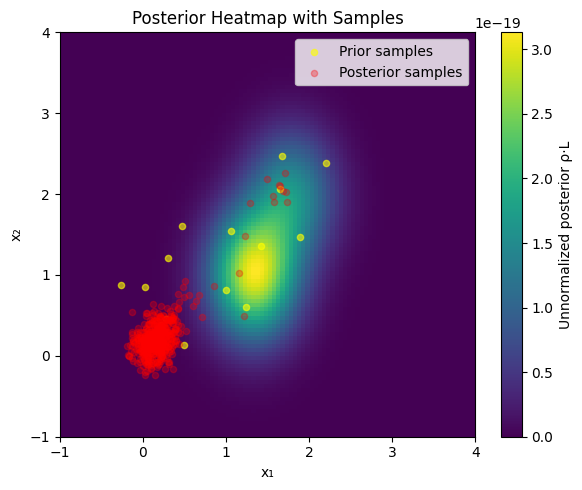

Mean distance to the nearest sample: 6.471538543701172
Mean distance to the center: 1.1832935810089111
KSD to the unnormalized posterior density: 17.819215774536133


In [36]:

def average_cosine_similarity(A: torch.Tensor, 
                              B: torch.Tensor, 
                              eps: float = 1e-8) -> torch.Tensor:
    """
    Compute the average row-wise cosine similarity between two tensors A and B.

    Args:
        A (torch.Tensor): Tensor of shape (N, 2).
        B (torch.Tensor): Tensor of shape (N, 2).
        eps (float): Small value to avoid division by zero.

    Returns:
        torch.Tensor: Scalar tensor containing the mean cosine similarity.
    """
    # 1. compute row-wise dot products, shape (N,)
    dot = torch.sum(A * B, dim=1)

    # 2. compute row-wise L2 norms, each shape (N,)
    normA = torch.norm(A, p=2, dim=1)
    normB = torch.norm(B, p=2, dim=1)

    # 3. cosine similarity per row
    cos_sim = dot / (normA * normB + eps)

    # 4. return the mean cosine similarity
    return cos_sim.mean()

# ———————————————
# Posterior sampling with MC guidance (flow + guidance)
# ———————————————

torch.manual_seed(42)
# 1. Draw MC target samples once (for guidance)
x1_samples = sample_q(N_mc, mus, covs, weights)    # [N_mc, 2]

# 2. Initialize reference points from the prior
# X_post = sample_q(N_gen, mus, covs, weights)       # [N_gen, 2]
X_post = torch.randn(N_gen, d)

# 3. Define energy J(x) = - log likelihood
def J_fn(x): 
    return compute_J(x, y_obs, H, sigma_obs)                                

def _v_fn(X, t):
    return velocity_field(X, t, x1_samples, sigma_min=0.2, method='mc')

X0 = X_post
# 4. Euler integration: base flow v_t + MC guidance g_t
for i in range(L_steps):
    t_i    = i * dt
    v_base = velocity_field(X_post, t_i, x1_samples, sigma_min=1e-1, method='mc')
    if t_i > 0:
        dot_xt_unguided = shifted_nearest_rows(X0, X_post, x1_samples, t_i) 
    else:
        dot_xt_unguided = v_base
    # dot_xt_unguided = v_base
    g = guidance(X_post, x1_samples, t_i, sigma_min=1e-1, J_fn=J_fn, dot_xt_unguided=dot_xt_unguided, method='affine-gm', M=200, v_fn=lambda x: _v_fn(x, t_i))             # [N_gen, 2]
    # cos_sim = average_cosine_similarity(v_base, g)
    # print(cos_sim)
    X_post = X_post + dt * (v_base + g)

visualize_posterior(grid_specs, prior2d, post2d,
                    X_post, x1_samples)

mean_dist_nearest, _ = compute_nearest_distance_stats(X_post, x1_samples)
print("Mean distance to the nearest sample:", mean_dist_nearest.item())
mean_dist = torch.mean(torch.sqrt(torch.sum((X_post - X_post.mean(dim=0))**2, dim=1)))
print("Mean distance to the center:", mean_dist.item())

ksd = compute_ksd_numeric(samples=X_post, f=post_fn, bandwidth=1)
print("KSD to the unnormalized posterior density:", ksd.item())


In [ ]:
import torch

# compute distance matrix
dist_mat = torch.cdist(X_post, x1_samples)
print(dist_mat.shape)  # e.g. (N, M)

# get the minimum distance for each row: returns (values, indices)
min_vals, _ = torch.min(dist_mat, dim=1)

# now take the maximum over those minima
maxmin_d = torch.max(min_vals)

print("The maximum of the minimal distance between each posterior samples to all prior samples", maxmin_d)


torch.Size([5000, 15])
The maximum of the minimal distance between each posterior samples to all prior samples tensor(0.7724)
